In [1]:
import sys
import os
import torch

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import os
import torch

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [4]:
from src.trainer import IntervalTrainer

In [4]:
import random
from typing import List, Tuple

# Simple GridWorld environment
class GridWorld:
    def __init__(self, width=5, height=5, obstacles=None, goal=(4, 4), start=(0, 0), max_steps=50):
        self.width = width
        self.height = height
        self.obstacles = set(obstacles or {(1,1), (1,2), (2,2)})
        self.goal = goal
        self.start = start
        self.max_steps = max_steps
        self.reset()

    def reset(self):
        self.pos = self.start
        self.steps = 0
        return self._state()

    def _state(self):
        # One-hot over grid cells
        idx = self.pos[1] * self.width + self.pos[0]
        s = torch.zeros(self.width * self.height, dtype=torch.float32)
        s[idx] = 1.0
        return s

    def step(self, action: int):
        x, y = self.pos
        if action == 0:    # up
            y2 = y - 1
            x2 = x
        elif action == 1:  # down
            y2 = y + 1
            x2 = x
        elif action == 2:  # left
            x2 = x - 1
            y2 = y
        elif action == 3:  # right
            x2 = x + 1
            y2 = y
        else:
            x2, y2 = x, y

        # Boundary / obstacle check
        if not (0 <= x2 < self.width and 0 <= y2 < self.height) or (x2, y2) in self.obstacles:
            x2, y2 = x, y
            penalty = -0.1
        else:
            penalty = -0.01

        self.pos = (x2, y2)
        self.steps += 1

        done = self.pos == self.goal or self.steps >= self.max_steps
        reward = 1.0 if self.pos == self.goal else penalty
        return self._state(), reward, done

    def safe_actions_mask(self, pos):
        mask = torch.zeros(4, dtype=torch.float32)
        x, y = pos
        deltas = {0:(0,-1), 1:(0,1), 2:(-1,0), 3:(1,0)}
        for a,(dx,dy) in deltas.items():
            nx, ny = x+dx, y+dy
            if 0 <= nx < self.width and 0 <= ny < self.height and (nx, ny) not in self.obstacles:
                mask[a] = 1.0
        return mask

# Policy network
class PolicyNet(torch.nn.Module):
    def __init__(self, state_dim, hidden=64, n_actions=4):
        super().__init__()
        self.net = torch.nn.Sequential(
            torch.nn.Linear(state_dim, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, hidden),
            torch.nn.ReLU(),
            torch.nn.Linear(hidden, n_actions)
        )
    def forward(self, x):
        return self.net(x)

# Instantiate environment and policy
env = GridWorld()
state_dim = env.width * env.height
n_actions = 4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PolicyNet(state_dim, hidden=64, n_actions=n_actions).to(device)
# Alternative approach: Define the policy as a Sequential model directly
# This would eliminate the need for the wrapper class
# sequential_policy = torch.nn.Sequential(
#     torch.nn.Linear(state_dim, 64),
#     torch.nn.ReLU(),
#     torch.nn.Linear(64, 64),
#     torch.nn.ReLU(),
#     torch.nn.Linear(64, n_actions)
# ).to(device)
# 
# # Then you could use it directly:
# # interval_trainer = IntervalTrainer(model=sequential_policy, seed=2025)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

# REINFORCE training
def train_policy(episodes=600):
    gamma = 0.99
    for ep in range(episodes):
        log_probs: List[torch.Tensor] = []
        rewards: List[float] = []
        state = env.reset().to(device)
        done = False
        while not done:
            logits = model(state.unsqueeze(0))
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))
            next_state, reward, done = env.step(action.item())
            rewards.append(reward)
            state = next_state.to(device)

        # Compute returns
        G = 0.0
        returns = []
        for r in reversed(rewards):
            G = r + gamma * G
            returns.append(G)
        returns.reverse()
        returns = torch.tensor(returns, dtype=torch.float32, device=device)
        if returns.std() > 1e-6:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = -(torch.stack(log_probs) * returns).sum()
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if (ep + 1) % 100 == 0:
            avg_return = sum(rewards)
            print(f"Episode {ep+1}: return={avg_return:.2f}, loss={loss.item():.3f}")

train_policy(episodes=1_000)

# Build dataset: one sample per state with safe action mask
dataset: List[Tuple[torch.Tensor, torch.Tensor]] = []
for y in range(env.height):
    for x in range(env.width):
        if (x, y) in env.obstacles:
            continue
        idx = y * env.width + x
        s = torch.zeros(state_dim, dtype=torch.float32)
        s[idx] = 1.0
        mask = env.safe_actions_mask((x, y))
        dataset.append((s, mask))

print(f"Dataset size (states without obstacles): {len(dataset)}")

Episode 100: return=-1.85, loss=-0.000
Episode 200: return=-2.12, loss=0.000
Episode 200: return=-2.12, loss=0.000
Episode 300: return=-2.39, loss=-0.000
Episode 300: return=-2.39, loss=-0.000
Episode 400: return=-2.66, loss=0.000
Episode 400: return=-2.66, loss=0.000
Episode 500: return=0.07, loss=0.000
Episode 500: return=0.07, loss=0.000
Episode 600: return=-2.01, loss=0.000
Episode 600: return=-2.01, loss=0.000
Episode 700: return=-4.10, loss=-0.000
Episode 700: return=-4.10, loss=-0.000
Episode 800: return=-3.47, loss=-0.000
Episode 800: return=-3.47, loss=-0.000
Episode 900: return=-2.66, loss=0.000
Episode 900: return=-2.66, loss=0.000
Episode 1000: return=-1.85, loss=0.000
Dataset size (states without obstacles): 22
Episode 1000: return=-1.85, loss=0.000
Dataset size (states without obstacles): 22


In [5]:
# Compute one-step safe actions for every non-obstacle state
# Actions: 0=up, 1=down, 2=left, 3=right
action_names = ['up', 'down', 'left', 'right']
safe_actions_per_state = {}

for y in range(env.height):
    for x in range(env.width):
        if (x, y) in env.obstacles:
            continue
        m = env.safe_actions_mask((x, y))
        indices = [i for i, v in enumerate(m.tolist()) if v == 1.0]
        safe_actions_per_state[(x, y)] = {
            "indices": indices,
            "names": [action_names[i] for i in indices]
        }

# Display
for coord, info in safe_actions_per_state.items():
    print(f"State {coord}: actions {info['indices']} ({info['names']})")

State (0, 0): actions [1, 3] (['down', 'right'])
State (1, 0): actions [2, 3] (['left', 'right'])
State (2, 0): actions [1, 2, 3] (['down', 'left', 'right'])
State (3, 0): actions [1, 2, 3] (['down', 'left', 'right'])
State (4, 0): actions [1, 2] (['down', 'left'])
State (0, 1): actions [0, 1] (['up', 'down'])
State (2, 1): actions [0, 3] (['up', 'right'])
State (3, 1): actions [0, 1, 2, 3] (['up', 'down', 'left', 'right'])
State (4, 1): actions [0, 1, 2] (['up', 'down', 'left'])
State (0, 2): actions [0, 1] (['up', 'down'])
State (3, 2): actions [0, 1, 3] (['up', 'down', 'right'])
State (4, 2): actions [0, 1, 2] (['up', 'down', 'left'])
State (0, 3): actions [0, 1, 3] (['up', 'down', 'right'])
State (1, 3): actions [1, 2, 3] (['down', 'left', 'right'])
State (2, 3): actions [1, 2, 3] (['down', 'left', 'right'])
State (3, 3): actions [0, 1, 2, 3] (['up', 'down', 'left', 'right'])
State (4, 3): actions [0, 1, 2] (['up', 'down', 'left'])
State (0, 4): actions [0, 3] (['up', 'right'])
Sta

In [6]:
# Build (state, action) supervised dataset: pick one safe action per state
state_action_dataset = []
for (x, y), info in safe_actions_per_state.items():
    safe_idxs = info["indices"]
    if not safe_idxs:
        continue
    action = random.choice(safe_idxs)  # label
    idx = y * env.width + x
    s = torch.zeros(state_dim, dtype=torch.float32)
    s[idx] = 1.0
    state_action_dataset.append((s, action))

print(f"Number of samples: {len(state_action_dataset)}")
print("First 5 samples (one-hot index -> action):")
for s, a in state_action_dataset[:5]:
    print(s.argmax().item(), "->", a, action_names[a])

Number of samples: 22
First 5 samples (one-hot index -> action):
0 -> 3 right
1 -> 3 right
2 -> 2 left
3 -> 2 left
4 -> 1 down


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

states = torch.stack([s for s, _ in state_action_dataset])
actions = torch.tensor([a for _, a in state_action_dataset], dtype=torch.long)

state_action_torch_dataset = TensorDataset(states, actions)
state_action_loader = DataLoader(state_action_torch_dataset, batch_size=8, shuffle=True)

print(f"Dataset size: {len(state_action_torch_dataset)}")
print("States shape:", states.shape, "Actions shape:", actions.shape)

interval_trainer = IntervalTrainer(
    model=model.net, # policy network's Sequential part
    seed=2025,
)

interval_trainer.compute_rashomon_set(
    dataset=state_action_torch_dataset, # states and safe actions; provide one sample per state
    )

Dataset size: 22
States shape: torch.Size([22, 25]) Actions shape: torch.Size([22])


Initial acc constraint violation: -0.0229 (Positive = violated)
Number of model parameters: 6084
Computing Rashomon set with min acc limit: 0.31
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.36,  Min acc soft=0.34


100%|██████████| 2000/2000 [00:11<00:00, 176.99it/s, size=17.35, obj=0.003, min_soft_acc=0.020]


Final bbox:  Obj=0.00,  Size=17.35,  Min acc hard=0.36,  Min acc soft=0.33
Computing final certificates over 256 samples
Num cert samples: 22
----------------------- Finished Computing Rashomon set ------------------------


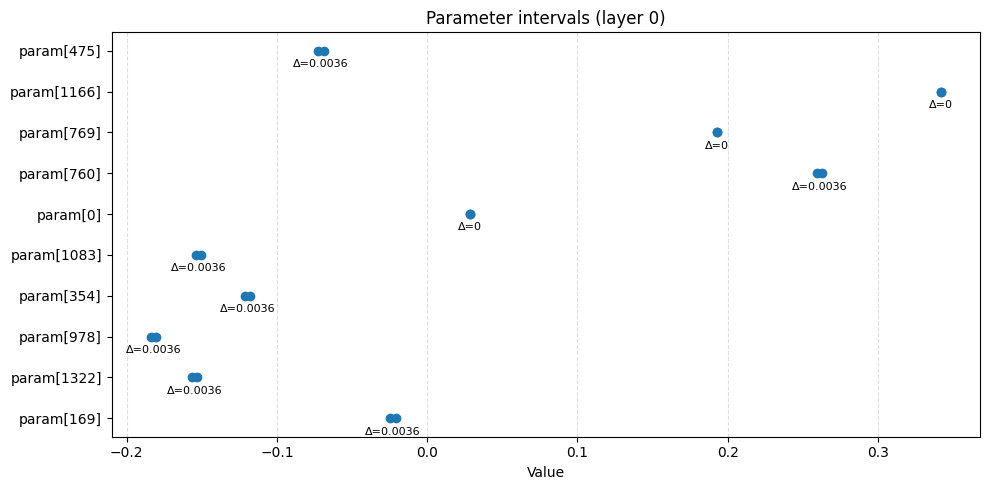

In [15]:
import matplotlib.pyplot as plt

layer_index = 0

# 3 linear layers, each has weight matrix and bias vector -> 6 elements in interval_trainer.bounds[0].param_l

# Access lower / upper bounds for first bounded parameter group
param_l = interval_trainer.bounds[0].param_l[layer_index].detach().cpu().view(-1)
param_u = interval_trainer.bounds[0].param_u[layer_index].detach().cpu().view(-1)
assert param_l.shape == param_u.shape, "Lower/upper bounds shape mismatch."

# Choose two parameter indices to visualize (change if desired)

num_elems = param_l.size()[0]
# generate 10 random indices
param_indices = random.sample(range(num_elems), 10)
intervals = []
for idx in param_indices:
    l = param_l[idx].item()
    u = param_u[idx].item()
    intervals.append((idx, l, u))

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
y_positions = range(len(intervals))
for y_pos, (pidx, l, u) in zip(y_positions, intervals):
    ax.hlines(y_pos, l, u, colors='tab:blue', linewidth=3)
    ax.plot([l, u], [y_pos, y_pos], 'o', color='tab:blue')
    # ax.text(u, y_pos + 0.2, f"{u:.2g}", fontsize=8)
    # ax.text(l, y_pos + 0.2, f"{l:.2g}", fontsize=8)
    ax.text((l + u) / 2, y_pos - 0.4, f"Δ={(u - l):.2g}", ha='center', fontsize=8)

ax.set_yticks(list(y_positions))
ax.set_yticklabels([f"param[{pidx}]" for pidx, _, _ in intervals])
ax.set_xlabel("Value")
ax.set_title(f"Parameter intervals (layer {layer_index})")
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# print(intervals) # Shows the raw (index, lower, upper) tuples

In [16]:
# Compute and display 5 widest parameter intervals for the current layer (uses existing param_l, param_u)
widths = param_u - param_l
topk = torch.topk(widths, k=5)
print(f"Top 5 widest parameter intervals (layer {layer_index}):")
for rank, (idx, w) in enumerate(zip(topk.indices.tolist(), topk.values.tolist()), 1):
    l = param_l[idx].item()
    u = param_u[idx].item()
    print(f"{rank}. param[{idx}]  lower={l:.6f}  upper={u:.6f}  width={w:.6f}")

Top 5 widest parameter intervals (layer 0):
1. param[26]  lower=-0.279702  upper=-0.276073  width=0.003629
2. param[101]  lower=-0.268160  upper=-0.264531  width=0.003629
3. param[305]  lower=-0.310888  upper=-0.307259  width=0.003629
4. param[102]  lower=-0.271013  upper=-0.267384  width=0.003629
5. param[25]  lower=-0.287573  upper=-0.283944  width=0.003629


### Continual learning

In [17]:
# Task 2: Projected Gradient Descent fine-tuning within Rashomon parameter bounds

# 1. Build a second (task 2) supervised dataset with different (alternative) safe action labels
orig_label_by_state_index = {s.argmax().item(): a for s, a in state_action_dataset}
task2_state_action_dataset = []
for (x, y), info in safe_actions_per_state.items():
    safe_idxs = info["indices"]
    if not safe_idxs:
        continue
    state_index = y * env.width + x
    orig = orig_label_by_state_index[state_index]
    # pick an alternative safe action if possible
    alt = [a for a in safe_idxs if a != orig]
    new_label = random.choice(alt) if alt else orig
    s = torch.zeros(state_dim, dtype=torch.float32)
    s[state_index] = 1.0
    task2_state_action_dataset.append((s, new_label))

# TensorDataset + DataLoader
task2_states = torch.stack([s for s, _ in task2_state_action_dataset])
task2_actions = torch.tensor([a for _, a in task2_state_action_dataset], dtype=torch.long)
task2_torch_dataset = TensorDataset(task2_states, task2_actions)
task2_loader = DataLoader(task2_torch_dataset, batch_size=8, shuffle=True)

print(f"Task2 dataset size: {len(task2_torch_dataset)}")

# 2. Prepare bounds (already computed by interval_trainer)
bounds_group = interval_trainer.bounds[0]
param_l_list = [p.detach().to(device) for p in bounds_group.param_l]
param_u_list = [p.detach().to(device) for p in bounds_group.param_u]

# 3. Optimizer for task 2
task2_optimizer = torch.optim.Adam(model.net.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

def project_params():
    with torch.no_grad():
        for p, l, u in zip(model.net.parameters(), param_l_list, param_u_list):
            p.clamp_(l, u)

# Evaluate (pre-adaptation) performance on Task 2 via average episodic return
with torch.no_grad():
    model.eval()
    eval_returns = []
    for s, _ in task2_state_action_dataset:
        state_idx = s.argmax().item()
        y = state_idx // env.width
        x = state_idx % env.width
        env.pos = (x, y)
        env.steps = 0

        ep_rewards = []
        done = False
        while not done:
            state_vec = env._state().to(device)
            logits = model.net(state_vec.unsqueeze(0))
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample()
            _, r, done = env.step(a.item())
            ep_rewards.append(r)

        eval_returns.append(sum(ep_rewards))

    pre_task2_avg_return = sum(eval_returns) / len(eval_returns) if eval_returns else 0.0
print(f"Pre-adaptation Task2 average episodic return: {pre_task2_avg_return:.4f}")

# 4. PGD fine-tuning loop (project after each update)
epochs = 30
gamma = 0.99

for epoch in range(1, epochs + 1):
    total_loss = 0.0
    model.train()
    for batch_states, _ in task2_loader:
        batch_states = batch_states.to(device)
        batch_losses = []
        state_indices = batch_states.argmax(dim=1).tolist()

        for state_idx in state_indices:
            y = state_idx // env.width
            x = state_idx % env.width
            env.pos = (x, y)
            env.steps = 0

            log_probs = []
            rewards = []
            done = False
            while not done:
                state_vec = env._state().to(device)
                logits = model.net(state_vec.unsqueeze(0))
                dist = torch.distributions.Categorical(logits=logits)
                action = dist.sample()
                log_probs.append(dist.log_prob(action))
                _, reward, done = env.step(action.item())
                rewards.append(reward)

            G = 0.0
            returns = []
            for r in reversed(rewards):
                G = r + gamma * G
                returns.append(G)
            returns.reverse()
            returns_t = torch.tensor(returns, dtype=torch.float32, device=device)
            if returns_t.std() > 1e-6:
                returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

            ep_loss = -(torch.stack(log_probs) * returns_t).sum()
            batch_losses.append(ep_loss)

        if batch_losses:
            loss = torch.stack(batch_losses).mean()
            task2_optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.net.parameters(), 1.0)
            task2_optimizer.step()
            project_params()
        else:
            loss = torch.tensor(0.0, device=device)

        total_loss += loss.item() * batch_states.size(0)

    avg_loss = total_loss / len(task2_torch_dataset)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch}: avg_loss={avg_loss:.4f}")

# 5. Verify all parameters are within bounds
with torch.no_grad():
    violations = 0
    for p, l, u in zip(model.net.parameters(), param_l_list, param_u_list):
        v_low = (p < l - 1e-7).sum().item()
        v_high = (p > u + 1e-7).sum().item()
        violations += v_low + v_high
    print(f"Parameter bound violations: {violations} (should be 0)")

# Evaluate (post-adaptation) performance on Task 2 via average episodic return
with torch.no_grad():
    model.eval()
    eval_returns = []
    for s, _ in task2_state_action_dataset:
        state_idx = s.argmax().item()
        y = state_idx // env.width
        x = state_idx % env.width
        env.pos = (x, y)
        env.steps = 0

        ep_rewards = []
        done = False
        while not done:
            state_vec = env._state().to(device)
            logits = model.net(state_vec.unsqueeze(0))
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample()
            _, r, done = env.step(a.item())
            ep_rewards.append(r)

        eval_returns.append(sum(ep_rewards))

    post_task2_avg_return = sum(eval_returns) / len(eval_returns) if eval_returns else 0.0
print(f"Post-adaptation Task2 average episodic return: {post_task2_avg_return:.4f}")

Task2 dataset size: 22
Pre-adaptation Task2 average episodic return: -1.1868
Epoch 1: avg_loss=-0.0001


/var/folders/29/nv2h4vrx5n9791kr6gs7kmfw0000gp/T/ipykernel_67353/997191256.py:104: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  if returns_t.std() > 1e-6:


Epoch 5: avg_loss=0.0564
Epoch 10: avg_loss=0.0727
Epoch 15: avg_loss=0.0787
Epoch 20: avg_loss=0.0564
Epoch 25: avg_loss=-0.0000
Epoch 30: avg_loss=0.0579
Parameter bound violations: 0 (should be 0)
Post-adaptation Task2 average episodic return: -0.6700


### Minigrid

In [28]:
import gymnasium as gym
from minigrid.core.grid import Grid
from minigrid.core.world_object import Goal, Wall
from minigrid.core.mission import MissionSpace
from minigrid.minigrid_env import MiniGridEnv

# MiniGrid custom environment with a goal and a few wall obstacles
try:
    import matplotlib.pyplot as plt
except ImportError as e:
    raise ImportError(
        "Install dependencies first: pip install gymnasium minigrid"
    ) from e

class ObstacleMiniGrid(MiniGridEnv):
    def __init__(self, size=7, obstacle_positions=None, max_steps=None):
        mission_space = MissionSpace(mission_func= lambda : "reach the green goal")
        super().__init__(
            mission_space=mission_space,
            grid_size=size,
            see_through_walls=False,
            max_steps=max_steps or 4 * size * size,
        )
        # Internal coords (exclude outer border walls)
        self.obstacle_positions = obstacle_positions or [(2, 2), (2, 3), (4, 3)]
        self.goal_pos = (size - 2, size - 2)

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        # Surrounding walls
        self.grid.wall_rect(0, 0, width, height)

        # Goal
        self.put_obj(Goal(), *self.goal_pos)

        # Obstacles (walls)
        for (ox, oy) in self.obstacle_positions:
            if (ox, oy) != self.goal_pos:
                self.put_obj(Wall(), ox, oy)

        # Agent start
        self.agent_pos = (1, 1)
        self.agent_dir = 0
        self.mission = "reach the goal"

# Instantiate environment
minigrid_env = ObstacleMiniGrid(size=7, render_mode="rgb_array")

obs, info = minigrid_env.reset(seed=123)
print("Observation keys:", list(obs.keys()))
print("Mission:", info.get("mission", ""))

# Render (RGB array) and display with existing matplotlib import
rgb = minigrid_env.render()
plt.figure(figsize=(3,3))
plt.imshow(rgb)
plt.title("MiniGrid with Obstacles")
plt.axis("off")
plt.show()

TypeError: ObstacleMiniGrid.__init__() got an unexpected keyword argument 'render_mode'

Unsafe (lava) positions: [(2, 2), (2, 3), (3, 2)]
Observation keys: ['image', 'direction', 'mission']


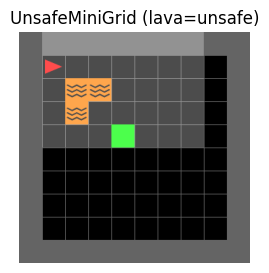

Unsafe state count: 3


In [40]:
# Custom MiniGrid environment highlighting unsafe (lava) states
from minigrid.core.world_object import Lava  # new object type (not imported earlier)

class UnsafeMiniGrid(MiniGridEnv):
    def __init__(self, size=7, unsafe_positions=None, goal_pos=None, max_steps=None):
        mission_space = MissionSpace(mission_func=lambda: "reach the green goal; avoid lava")
        super().__init__(
            mission_space=mission_space,
            grid_size=size,
            see_through_walls=False,
            max_steps=max_steps or 4 * size * size,
        )
        self.goal_pos = goal_pos or (size - 2, size - 2)
        self.unsafe_positions = unsafe_positions or [(2, 2), (2, 3), (3, 2)]

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)
        # Goal
        self.put_obj(Goal(), *self.goal_pos)
        # Unsafe (lava) tiles
        for (ux, uy) in self.unsafe_positions:
            if (ux, uy) != self.goal_pos:
                self.put_obj(Lava(), ux, uy)
        # Agent start
        self.agent_pos = (1, 1)
        self.agent_dir = 0
        self.mission = "reach the goal without stepping on lava"

    def render(self):
        # Return an RGB numpy array of the full grid (agent_pov=False for full map)
        return self.get_frame(agent_pov=False)

# Instantiate and visualize
unsafe_env = UnsafeMiniGrid(size=10, goal_pos=(4,4), unsafe_positions=[(2,2), (2,3), (3,2)])
obs, info = unsafe_env.reset(seed=123)
print("Unsafe (lava) positions:", unsafe_env.unsafe_positions)
print("Observation keys:", list(obs.keys()))

rgb_img = unsafe_env.render()
if rgb_img is not None:
    plt.figure(figsize=(3,3))
    plt.imshow(rgb_img)
    plt.title("UnsafeMiniGrid (lava=unsafe)")
    plt.axis("off")
    plt.show()

# Collect unsafe state set (internal coordinates only)
unsafe_states = set(unsafe_env.unsafe_positions)
print("Unsafe state count:", len(unsafe_states))

In [42]:
# REINFORCE training for unsafe_env (MiniGrid) with a simple MLP policy

# 1. Feature builder
def obs_to_tensor(obs):
    img = torch.from_numpy(obs["image"]).float() / 255.0   # (7,7,3) uint8 -> float
    flat = img.view(-1)
    dir_oh = torch.nn.functional.one_hot(torch.tensor(obs["direction"]), num_classes=4).float()
    feat = torch.cat([flat, dir_oh], dim=0)
    return feat.to(device)

# 2. Build policy network (only once)
_sample_obs, _ = unsafe_env.reset(seed=0)
in_dim = obs_to_tensor(_sample_obs).numel()
n_act = unsafe_env.action_space.n

mg_model = torch.nn.Sequential(
    torch.nn.Linear(in_dim, 128),
    torch.nn.ReLU(),
    torch.nn.Linear(128, 64),
    torch.nn.ReLU(),
    torch.nn.Linear(64, n_act),
).to(device)

mg_optimizer = torch.optim.Adam(mg_model.parameters(), lr=1e-3)

# 3. REINFORCE
def train_minigrid_reinforce(env, episodes=800, gamma=0.99, log_interval=100):
    returns_history = []
    for ep in range(1, episodes + 1):
        log_probs = []
        rewards = []
        obs, _ = env.reset()
        done = False
        while not done:
            x = obs_to_tensor(obs).unsqueeze(0)
            logits = mg_model(x)
            dist = torch.distributions.Categorical(logits=logits)
            act = dist.sample()
            log_probs.append(dist.log_prob(act))
            obs, reward, terminated, truncated, _ = env.step(act.item())
            # Optional extra penalty for lava (unsafe) tiles
            if env.agent_pos in env.unsafe_positions:
                reward -= 0.5
            rewards.append(reward)
            done = terminated or truncated

        # Compute discounted returns
        G = 0.0
        disc = []
        for r in reversed(rewards):
            G = r + gamma * G
            disc.append(G)
        disc.reverse()
        returns_t = torch.tensor(disc, dtype=torch.float32, device=device)
        if returns_t.std() > 1e-6:
            returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

        loss = -(torch.stack(log_probs) * returns_t).sum()

        mg_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(mg_model.parameters(), 1.0)
        mg_optimizer.step()

        ep_return = sum(rewards)
        returns_history.append(ep_return)

        if ep % log_interval == 0:
            avg_last = sum(returns_history[-log_interval:]) / log_interval
            print(f"[Ep {ep}] avg_return(last {log_interval}) = {avg_last:.3f}")

    return returns_history

# 4. Quick greedy evaluation
def evaluate(env, episodes=50):
    total = 0.0
    successes = 0
    for _ in range(episodes):
        obs, _ = env.reset()
        done = False
        ep_r = 0.0
        while not done:
            with torch.no_grad():
                x = obs_to_tensor(obs).unsqueeze(0)
                logits = mg_model(x)
                action = torch.argmax(logits, dim=1).item()
            obs, reward, terminated, truncated, _ = env.step(action)
            if env.agent_pos in env.unsafe_positions:
                reward -= 0.5
            ep_r += reward
            done = terminated or truncated
            if terminated and reward > 0:  # goal reached
                successes += 1
        total += ep_r
    print(f"Eval: avg_return={total/episodes:.3f}, success_rate={successes/episodes:.2%}")


returns_unsafe = train_minigrid_reinforce(unsafe_env, episodes=10_000)
evaluate(unsafe_env, episodes=50)

[Ep 100] avg_return(last 100) = -0.332
[Ep 200] avg_return(last 100) = -0.377
[Ep 200] avg_return(last 100) = -0.377
[Ep 300] avg_return(last 100) = -0.378
[Ep 300] avg_return(last 100) = -0.378
[Ep 400] avg_return(last 100) = -0.285
[Ep 400] avg_return(last 100) = -0.285
[Ep 500] avg_return(last 100) = -0.345
[Ep 500] avg_return(last 100) = -0.345
[Ep 600] avg_return(last 100) = -0.376
[Ep 600] avg_return(last 100) = -0.376
[Ep 700] avg_return(last 100) = -0.372
[Ep 700] avg_return(last 100) = -0.372
[Ep 800] avg_return(last 100) = -0.342
[Ep 800] avg_return(last 100) = -0.342
[Ep 900] avg_return(last 100) = -0.352
[Ep 900] avg_return(last 100) = -0.352
[Ep 1000] avg_return(last 100) = -0.343
[Ep 1000] avg_return(last 100) = -0.343
[Ep 1100] avg_return(last 100) = -0.378
[Ep 1100] avg_return(last 100) = -0.378
[Ep 1200] avg_return(last 100) = -0.334
[Ep 1200] avg_return(last 100) = -0.334
[Ep 1300] avg_return(last 100) = -0.312
[Ep 1300] avg_return(last 100) = -0.312
[Ep 1400] avg_ret

### Frozen Lake with full observability

In [45]:
import gymnasium as gym

In [ ]:
frozen_lake_env1 = gym.make(
    "FrozenLake-v1", is_slippery=False,
    desc=[
        "SFFF",
        "FHFH",
        "FFFH",
        "FHFH",
        "FFFH",
        "FHFH",
        "FFFH",
        "FHFH",
        "FFFH",
        "HFFG"
    ]
)
# REINFORCE for FrozenLake (deterministic, non-slippery)

state_dim = frozen_lake_env1.observation_space.n
action_dim = frozen_lake_env1.action_space.n

frozen_policy = torch.nn.Sequential(
    torch.nn.Linear(state_dim, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, action_dim)
).to(device)

frozen_optimizer = torch.optim.Adam(frozen_policy.parameters(), lr=1e-1)
gamma_fl = 0.99
episodes_fl = 4000
log_interval = 500

def one_hot(s):
    v = torch.zeros(state_dim, device=device)
    v[s] = 1.0
    return v

ret_history = []

for ep in range(1, episodes_fl + 1):
    log_probs = []
    rewards = []
    obs, _ = frozen_lake_env1.reset()
    done = False
    while not done:
        s_vec = one_hot(obs).unsqueeze(0)
        logits = frozen_policy(s_vec)
        dist = torch.distributions.Categorical(logits=logits)
        act = dist.sample()
        log_probs.append(dist.log_prob(act))
        obs, r, terminated, truncated, _ = frozen_lake_env1.step(act.item())
        rewards.append(r)
        done = terminated or truncated

    # returns
    G = 0.0
    returns = []
    for r in reversed(rewards):
        G = r * 1.0 + gamma_fl * G
        returns.append(G)
    returns.reverse()
    returns_t = torch.tensor(returns, dtype=torch.float32, device=device)
    if returns_t.std() > 1e-8:
        returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

    loss = -(torch.stack(log_probs) * returns_t).sum()
    frozen_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(frozen_policy.parameters(), 1.0)
    frozen_optimizer.step()

    ep_ret = sum(rewards)
    ret_history.append(ep_ret)

    if ep % log_interval == 0:
        avg_last = sum(ret_history[-log_interval:]) / log_interval
        print(f"[FrozenLake ep {ep}] avg_return={avg_last:.3f}")

# Evaluation (greedy)
def eval_frozen(env, episodes=200):
    wins = 0
    for _ in range(episodes):
        obs, _ = env.reset()
        done = False
        while not done:
            with torch.no_grad():
                logits = frozen_policy(one_hot(obs).unsqueeze(0))
                act = torch.argmax(logits, dim=1).item()
            obs, r, terminated, truncated, _ = env.step(act)
            done = terminated or truncated
            if terminated and r == 1.0:
                wins += 1
    print(f"Greedy success rate: {wins/episodes:.2%}")

eval_frozen(frozen_lake_env1, episodes=200)


[FrozenLake ep 500] avg_return=0.000
[FrozenLake ep 1000] avg_return=0.000
[FrozenLake ep 1000] avg_return=0.000
[FrozenLake ep 1500] avg_return=0.000
[FrozenLake ep 1500] avg_return=0.000
[FrozenLake ep 2000] avg_return=0.000
[FrozenLake ep 2000] avg_return=0.000
[FrozenLake ep 2500] avg_return=0.000
[FrozenLake ep 2500] avg_return=0.000
[FrozenLake ep 3000] avg_return=0.000
[FrozenLake ep 3000] avg_return=0.000
[FrozenLake ep 3500] avg_return=0.000
[FrozenLake ep 3500] avg_return=0.000
[FrozenLake ep 4000] avg_return=0.000
[FrozenLake ep 4000] avg_return=0.000
Greedy success rate: 0.00%
Greedy success rate: 0.00%


[FrozenLake ep 500] avg_return=0.000
[FrozenLake ep 1000] avg_return=0.000
[FrozenLake ep 1000] avg_return=0.000
[FrozenLake ep 1500] avg_return=0.000
[FrozenLake ep 1500] avg_return=0.000
[FrozenLake ep 2000] avg_return=0.000
[FrozenLake ep 2000] avg_return=0.000
[FrozenLake ep 2500] avg_return=0.000
[FrozenLake ep 2500] avg_return=0.000
[FrozenLake ep 3000] avg_return=0.000
[FrozenLake ep 3000] avg_return=0.000
[FrozenLake ep 3500] avg_return=0.000
[FrozenLake ep 3500] avg_return=0.000
[FrozenLake ep 4000] avg_return=0.000
[FrozenLake ep 4000] avg_return=0.000
Greedy success rate: 0.00%
Greedy success rate: 0.00%


: 

In [7]:
import argparse
from dataclasses import dataclass
from typing import Tuple, List

import numpy as np
import gymnasium as gym
from gymnasium import spaces

import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# =========================
# Potential-based shaping (optional)
# =========================
def manhattan_phi(state_idx: int, W: int, goal_rc: Tuple[int, int]):
    r, c = divmod(state_idx, W)
    gr, gc = goal_rc
    return - (abs(r - gr) + abs(c - gc))  # more negative far away


# =========================
# REINFORCE (episodic) with baseline + entropy
# =========================
class Policy(nn.Module):
    def __init__(self, nS: int, nA: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nS, hidden), nn.ReLU(),
            nn.Linear(hidden, nA)
        )

    def forward(self, s_idx: torch.Tensor):
        # s_idx: [B] long -> one-hot -> logits
        nS = self.net[0].in_features
        x = torch.nn.functional.one_hot(s_idx, num_classes=nS).float()
        logits = self.net(x)
        return torch.distributions.Categorical(logits=logits)


@dataclass
class TrainCfg:
    episodes: int = 4000
    gamma: float = 0.99
    lr: float = 3e-3
    entropy_coef: float = 0.01
    baseline_beta: float = 0.9  # running exponential mean of returns
    max_steps: int = 60
    shaping_beta: float = 0.0   # 0 disables shaping

    def train_reinforce(
        env: ReachAvoidGrid,
        cfg: TrainCfg,
        device="cpu",
        log_every=200,
        policy: Policy = None,          # pass an already constructed (possibly pretrained) Policy
        load_path: str = None,          # OR provide a torch.load path with a state_dict
        freeze: bool = False            # optionally freeze the warm-start policy (no further training)
    ):
        """
        REINFORCE with (optional) potential-based shaping and entropy bonus.
        Warm start options:
          - Pass an existing Policy instance via `policy`
          - Or pass a checkpoint path via `load_path`
        If both are given, `policy` is used then updated with the loaded state_dict (strict=False).
        """
        nS = env.observation_space.n
        nA = env.action_space.n

        # Initialize / load policy
        if policy is None:
            policy = Policy(nS, nA, hidden=64).to(device)
        else:
            policy = policy.to(device)

        if load_path is not None:
            state = torch.load(load_path, map_location=device)
            # allow partial load (strict=False) in case architecture changed slightly
            policy.load_state_dict(state, strict=False)

        # Sanity check dimensions
        assert policy.net[0].in_features == nS and policy.net[-1].out_features == nA, \
            "Pretrained policy architecture incompatible with environment action/state sizes."

        # Optionally freeze parameters (no further gradient updates)
        if freeze:
            for p in policy.parameters():
                p.requires_grad = False

        opt = optim.Adam([p for p in policy.parameters() if p.requires_grad], lr=cfg.lr) if not freeze else None

        running_baseline = 0.0
        success_window = []

        goal_rc = env.goal
        W = env.W

        for ep in range(cfg.episodes):
            logps, rewards, entropies, states = [], [], [], []
            s, _ = env.reset()
            for t in range(cfg.max_steps):
                s_t = torch.tensor([s], dtype=torch.long, device=device)
                dist = policy(s_t)
                a = dist.sample()
                logps.append(dist.log_prob(a).squeeze(0))
                entropies.append(dist.entropy().squeeze(0))
                states.append(s)

                s_next, r_env, terminated, truncated, _ = env.step(int(a.item()))

                if cfg.shaping_beta != 0.0:
                    phi_s = manhattan_phi(s, W, goal_rc)
                    phi_sn = manhattan_phi(s_next, W, goal_rc)
                    shaping = cfg.gamma * phi_sn - phi_s
                    r = r_env + cfg.shaping_beta * shaping
                else:
                    r = r_env

                rewards.append(float(r))
                s = s_next
                if terminated or truncated:
                    break

            # discounted returns
            G = 0.0
            returns = []
            for r in reversed(rewards):
                G = r + cfg.gamma * G
                returns.append(G)
            returns.reverse()

            if returns:
                running_baseline = cfg.baseline_beta * running_baseline + (1 - cfg.baseline_beta) * (np.mean(returns))

            if returns and not freeze:
                R = torch.tensor(returns, dtype=torch.float32, device=device)
                b = torch.tensor(running_baseline, dtype=torch.float32, device=device)
                adv = R - b

                logps_t = torch.stack(logps)
                ent_t = torch.stack(entropies)

                policy_loss = -(logps_t * adv).sum() - cfg.entropy_coef * ent_t.sum()
                opt.zero_grad()
                policy_loss.backward()
                opt.step()

            succeeded = 1.0 if (rewards and rewards[-1] >= 1.0) else 0.0
            success_window.append(succeeded)
            if len(success_window) > 100:
                success_window.pop(0)

            if (ep + 1) % log_every == 0:
                print(f"[REINFORCE] ep {ep+1:4d}/{cfg.episodes} | "
                      f"len={len(rewards):2d} | return={sum(rewards):+.3f} | "
                      f"success(100ep)={np.mean(success_window)*100:.1f}% | "
                      f"{'FROZEN' if freeze else 'TRAIN'}")

        def greedy_policy_fn(s: int) -> int:
            with torch.no_grad():
                s_t = torch.tensor([s], dtype=torch.long, device=device)
                dist = policy(s_t)
                return int(torch.argmax(dist.logits, dim=-1).item())

        return greedy_policy_fn, policy
    
def train_reinforce(env: ReachAvoidGrid, cfg: TrainCfg, device="cpu", pretrained_policy=None, log_every=200):
    nS = env.observation_space.n
    nA = env.action_space.n
    if pretrained_policy is not None:
        policy = pretrained_policy.to(device)
    else:
        policy = Policy(nS, nA, hidden=64).to(device)
    opt = optim.Adam(policy.parameters(), lr=cfg.lr)

    running_baseline = 0.0
    success_window = []

    # precompute goal coordinates for shaping
    goal_rc = env.goal
    W = env.W

    for ep in range(cfg.episodes):
        logps, rewards, entropies, states = [], [], [], []
        s, _ = env.reset()
        for t in range(cfg.max_steps):
            s_t = torch.tensor([s], dtype=torch.long, device=device)
            dist = policy(s_t)
            a = dist.sample()
            logps.append(dist.log_prob(a).squeeze(0))
            entropies.append(dist.entropy().squeeze(0))
            states.append(s)

            s_next, r_env, terminated, truncated, _ = env.step(int(a.item()))

            # potential-based shaping F = gamma*phi(s') - phi(s)
            if cfg.shaping_beta != 0.0:
                phi_s = manhattan_phi(s, W, goal_rc)
                phi_sn = manhattan_phi(s_next, W, goal_rc)
                shaping = cfg.gamma * phi_sn - phi_s
                r = r_env + cfg.shaping_beta * shaping
            else:
                r = r_env

            rewards.append(float(r))
            s = s_next
            if terminated or truncated:
                break

        # discounted returns
        G = 0.0
        returns = []
        for r in reversed(rewards):
            G = r + cfg.gamma * G
            returns.append(G)
        returns.reverse()

        # baseline (running mean of returns)
        if returns:
            ep_return = float(sum(rewards))  # same as episodic return
            running_baseline = cfg.baseline_beta * running_baseline + (1 - cfg.baseline_beta) * (np.mean(returns))

        if returns:
            R = torch.tensor(returns, dtype=torch.float32, device=device)
            b = torch.tensor(running_baseline, dtype=torch.float32, device=device)
            adv = R - b

            logps_t = torch.stack(logps)
            ent_t = torch.stack(entropies)

            policy_loss = -(logps_t * adv).sum() - cfg.entropy_coef * ent_t.sum()
            loss = policy_loss

            opt.zero_grad()
            loss.backward()
            opt.step()

        # crude success metric: +1 if episode ended at goal (env gives +1 last step when goal reached)
        succeeded = 1.0 if (rewards and rewards[-1] >= 1.0) else 0.0
        success_window.append(succeeded)
        if len(success_window) > 100:
            success_window.pop(0)

        if (ep + 1) % log_every == 0:
            print(f"[REINFORCE] ep {ep+1:4d}/{cfg.episodes} | "
                  f"len={len(rewards):2d} | return={sum(rewards):+.3f} | "
                  f"success(100ep)={np.mean(success_window)*100:.1f}%")

    # greedy policy for evaluation
    def greedy_policy_fn(s: int) -> int:
        with torch.no_grad():
            s_t = torch.tensor([s], dtype=torch.long, device=device)
            dist = policy(s_t)
            return int(torch.argmax(dist.logits, dim=-1).item())

    return greedy_policy_fn, policy


def evaluate(env: gym.Env, policy_fn, n_episodes=200, seed=123) -> float:
    rng = np.random.default_rng(seed)
    wins = 0
    for _ in range(n_episodes):
        s, _ = env.reset(seed=int(rng.integers(0, 10_000)))
        done = False
        while not done:
            a = policy_fn(s)
            s, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            if terminated and r >= 1.0:
                wins += 1
                break
    return wins / n_episodes

In [35]:
# Build (state, action) supervised dataset: pick one safe action per state
state_action_dataset = []
for (x, y), info in safe_actions_per_state.items():
    safe_idxs = info["indices"]
    if not safe_idxs:
        continue
    action = random.choice(safe_idxs)  # label
    idx = y * env.width + x
    s = torch.zeros(state_dim, dtype=torch.float32)
    s[idx] = 1.0
    state_action_dataset.append((s, action))

print(f"Number of samples: {len(state_action_dataset)}")
print("First 5 samples (one-hot index -> action):")
for s, a in state_action_dataset[:5]:
    print(s.argmax().item(), "->", a, action_names[a])

Number of samples: 22
First 5 samples (one-hot index -> action):
0 -> 3 right
1 -> 3 right
2 -> 2 left
3 -> 2 left
4 -> 1 down


In [41]:
size = 5
episodes = 4000
slip = 0.0
step_penalty = 0.0
lava_penalty = 0.0
shaping_beta = 0.0
seed = 42

H = W = size
# A simple vertical lava wall with a gap—classic reach-avoid layout
lava = [(r, W // 2) for r in range(1, H - 1)]  # leave top/bottom as potential gaps
# open a gap to make it solvable
if H >= 5:
    gap_r = H // 2
    lava = [cell for cell in lava if cell[0] != gap_r]

env = ReachAvoidGrid(
    height=H, width=W,
    start=(0, 0),
    goal=(H - 1, W - 1),
    lava=lava,
    slip=slip,
    step_penalty=step_penalty,
    lava_penalty=lava_penalty,
    max_steps=H * W + 10,
    seed=seed,
)

cfg = TrainCfg(
    episodes=episodes,
    shaping_beta=shaping_beta,
)
policy_fn, policy_network = train_reinforce(env, cfg, device="cpu")

sr = evaluate(env, policy_fn, n_episodes=300, seed=seed + 7)
print(f"\nEvaluation success rate: {sr*100:.1f}% over 300 episodes")


[REINFORCE] ep  200/4000 | len=14 | return=+0.000 | success(100ep)=53.0%
[REINFORCE] ep  400/4000 | len=18 | return=+1.000 | success(100ep)=95.0%
[REINFORCE] ep  600/4000 | len=11 | return=+1.000 | success(100ep)=98.0%
[REINFORCE] ep  800/4000 | len= 8 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep 1000/4000 | len= 8 | return=+1.000 | success(100ep)=98.0%
[REINFORCE] ep 1200/4000 | len= 8 | return=+1.000 | success(100ep)=99.0%
[REINFORCE] ep 1400/4000 | len= 8 | return=+1.000 | success(100ep)=97.0%
[REINFORCE] ep 1600/4000 | len=14 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep 1800/4000 | len= 9 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep 2000/4000 | len= 9 | return=+1.000 | success(100ep)=98.0%
[REINFORCE] ep 2200/4000 | len= 9 | return=+1.000 | success(100ep)=99.0%
[REINFORCE] ep 2400/4000 | len=11 | return=+1.000 | success(100ep)=99.0%
[REINFORCE] ep 2600/4000 | len=11 | return=+1.000 | success(100ep)=99.0%
[REINFORCE] ep 2800/4000 | len= 9 | return=+1.00

In [42]:
env.render()

. . . . .
. . L . .
. . . . .
. . L . .
. . . . A 



### TODOs
-- bigger grid world
-- maybe continuous actions?
-- simple invariance safety property for a big task (Atari games with noisy input distribution?)

Baselines:
-- no weight constraints
-- EWC
-- regularisation (with L2 distance to previous policy)

(most) methods are not provable, they use heuristics;

Limitations:
-- one-step safety in experiments;
-- currently only discrete states and actions;

In [38]:
new_env = ReachAvoidGrid(
    height=H, width=W,
    start=(0, 0),
    goal=(H - 2, W - 2),
    lava=None,
    slip=slip,
    step_penalty=step_penalty,
    lava_penalty=lava_penalty,
    max_steps=H * W + 10,
    seed=seed,
)
new_env.render()

A . . . .
. . . . .
. . . . .
. . . G .
. . . . . 



### Scenario
- Task 1: goal at (x1, y1); unsafe set X_u
- Task 2: goal at (x2, y2); the same unsafe set X_u or subset of X_u

In [40]:
cfg = TrainCfg(
    episodes=episodes,
    shaping_beta=shaping_beta,
)


train_reinforce(env=new_env, cfg=cfg, pretrained_policy=policy_network)

sr = evaluate(new_env, policy_fn, n_episodes=300, seed=seed + 7)
print(f"\nEvaluation success rate: {sr*100:.1f}% over 300 episodes")

[REINFORCE] ep  200/4000 | len= 6 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep  400/4000 | len= 6 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep  400/4000 | len= 6 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep  600/4000 | len= 8 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep  600/4000 | len= 8 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep  800/4000 | len= 9 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep  800/4000 | len= 9 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep 1000/4000 | len= 7 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep 1000/4000 | len= 7 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep 1200/4000 | len= 8 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep 1200/4000 | len= 8 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep 1400/4000 | len=10 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep 1400/4000 | len=10 | return=+1.000 | success(100ep)=100.0%
[REINFORCE] ep 1600/4000 | len= 8 | re

In [8]:
interval_trainer = IntervalTrainer(
    model=model.net, # policy network's Sequential part
    seed=2025,
)

interval_trainer.compute_rashomon_set(
    dataset=state_action_torch_dataset, # states and safe actions; provide one sample per state
    )

Initial acc constraint violation: -0.0229 (Positive = violated)
Number of model parameters: 6084
Computing Rashomon set with min acc limit: 0.31
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.36,  Min acc soft=0.34


100%|██████████| 2000/2000 [00:11<00:00, 176.99it/s, size=17.35, obj=0.003, min_soft_acc=0.020]


Initial acc constraint violation: -0.0229 (Positive = violated)
Number of model parameters: 6084
Computing Rashomon set with min acc limit: 0.31
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.36,  Min acc soft=0.34


100%|██████████| 2000/2000 [00:11<00:00, 176.99it/s, size=17.35, obj=0.003, min_soft_acc=0.020]


Final bbox:  Obj=0.00,  Size=17.35,  Min acc hard=0.36,  Min acc soft=0.33
Computing final certificates over 256 samples
Num cert samples: 22
----------------------- Finished Computing Rashomon set ------------------------


In [ ]:
import gymnasium as gym
from minigrid.core.grid import Grid
from minigrid.core.world_object import Goal, Wall
from minigrid.core.mission import MissionSpace
from minigrid.minigrid_env import MiniGridEnv

# MiniGrid custom environment with a goal and a few wall obstacles
try:
except ImportError as e:
    raise ImportError(
        "Install dependencies first: pip install gymnasium minigrid"
    ) from e

class ObstacleMiniGrid(MiniGridEnv):
    def __init__(self, size=7, obstacle_positions=None, max_steps=None):
        mission_space = MissionSpace(missions=["reach the green goal"])
        super().__init__(
            mission_space=mission_space,
            grid_size=size,
            see_through_walls=False,
            max_steps=max_steps or 4 * size * size,
        )
        # Internal coords (exclude outer border walls)
        self.obstacle_positions = obstacle_positions or [(2, 2), (2, 3), (4, 3)]
        self.goal_pos = (size - 2, size - 2)

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        # Surrounding walls
        self.grid.wall_rect(0, 0, width, height)

        # Goal
        self.put_obj(Goal(), *self.goal_pos)

        # Obstacles (walls)
        for (ox, oy) in self.obstacle_positions:
            if (ox, oy) != self.goal_pos:
                self.put_obj(Wall(), ox, oy)

        # Agent start
        self.agent_pos = (1, 1)
        self.agent_dir = 0
        self.mission = "reach the goal"

# Instantiate environment
minigrid_env = ObstacleMiniGrid(size=7)

obs, info = minigrid_env.reset(seed=123)
print("Observation keys:", list(obs.keys()))
print("Mission:", info.get("mission", ""))

# Render (RGB array) and display with existing matplotlib import
rgb = minigrid_env.render()
plt.figure(figsize=(3,3))
plt.imshow(rgb)
plt.title("MiniGrid with Obstacles")
plt.axis("off")
plt.show()

Unsafe (lava) positions: [(2, 2), (2, 3), (3, 2)]
Observation keys: ['image', 'direction', 'mission']


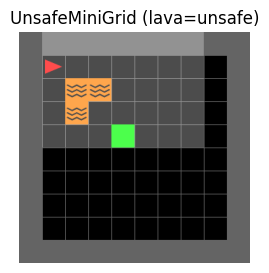

Unsafe state count: 3


In [40]:
# Custom MiniGrid environment highlighting unsafe (lava) states
from minigrid.core.world_object import Lava  # new object type (not imported earlier)

class UnsafeMiniGrid(MiniGridEnv):
    def __init__(self, size=7, unsafe_positions=None, goal_pos=None, max_steps=None):
        mission_space = MissionSpace(mission_func=lambda: "reach the green goal; avoid lava")
        super().__init__(
            mission_space=mission_space,
            grid_size=size,
            see_through_walls=False,
            max_steps=max_steps or 4 * size * size,
        )
        self.goal_pos = goal_pos or (size - 2, size - 2)
        self.unsafe_positions = unsafe_positions or [(2, 2), (2, 3), (3, 2)]

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)
        # Goal
        self.put_obj(Goal(), *self.goal_pos)
        # Unsafe (lava) tiles
        for (ux, uy) in self.unsafe_positions:
            if (ux, uy) != self.goal_pos:
                self.put_obj(Lava(), ux, uy)
        # Agent start
        self.agent_pos = (1, 1)
        self.agent_dir = 0
        self.mission = "reach the goal without stepping on lava"

    def render(self):
        # Return an RGB numpy array of the full grid (agent_pov=False for full map)
        return self.get_frame(agent_pov=False)

# Instantiate and visualize
unsafe_env = UnsafeMiniGrid(size=10, goal_pos=(4,4), unsafe_positions=[(2,2), (2,3), (3,2)])
obs, info = unsafe_env.reset(seed=123)
print("Unsafe (lava) positions:", unsafe_env.unsafe_positions)
print("Observation keys:", list(obs.keys()))

rgb_img = unsafe_env.render()
if rgb_img is not None:
    plt.figure(figsize=(3,3))
    plt.imshow(rgb_img)
    plt.title("UnsafeMiniGrid (lava=unsafe)")
    plt.axis("off")
    plt.show()

# Collect unsafe state set (internal coordinates only)
unsafe_states = set(unsafe_env.unsafe_positions)
print("Unsafe state count:", len(unsafe_states))

In [79]:
# Task 2: Projected Gradient Descent fine-tuning within Rashomon parameter bounds

# 1. Build a second (task 2) supervised dataset with different (alternative) safe action labels
orig_label_by_state_index = {s.argmax().item(): a for s, a in state_action_dataset}
task2_state_action_dataset = []
for (x, y), info in safe_actions_per_state.items():
    safe_idxs = info["indices"]
    if not safe_idxs:
        continue
    state_index = y * env.width + x
    orig = orig_label_by_state_index[state_index]
    # pick an alternative safe action if possible
    alt = [a for a in safe_idxs if a != orig]
    new_label = random.choice(alt) if alt else orig
    s = torch.zeros(state_dim, dtype=torch.float32)
    s[state_index] = 1.0
    task2_state_action_dataset.append((s, new_label))

# TensorDataset + DataLoader
task2_states = torch.stack([s for s, _ in task2_state_action_dataset])
task2_actions = torch.tensor([a for _, a in task2_state_action_dataset], dtype=torch.long)
task2_torch_dataset = TensorDataset(task2_states, task2_actions)
task2_loader = DataLoader(task2_torch_dataset, batch_size=8, shuffle=True)

print(f"Task2 dataset size: {len(task2_torch_dataset)}")

# 2. Prepare bounds (already computed by interval_trainer)
bounds_group = interval_trainer.bounds[0]
param_l_list = [p.detach().to(device) for p in bounds_group.param_l]
param_u_list = [p.detach().to(device) for p in bounds_group.param_u]

# 3. Optimizer for task 2
task2_optimizer = torch.optim.Adam(model.net.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

def project_params():
    with torch.no_grad():
        for p, l, u in zip(model.net.parameters(), param_l_list, param_u_list):
            p.clamp_(l, u)

# Evaluate (pre-adaptation) performance on Task 2 via average episodic return
with torch.no_grad():
    model.eval()
    eval_returns = []
    for s, _ in task2_state_action_dataset:
        state_idx = s.argmax().item()
        y = state_idx // env.width
        x = state_idx % env.width
        env.pos = (x, y)
        env.steps = 0

        ep_rewards = []
        done = False
        while not done:
            state_vec = env._state().to(device)
            logits = model.net(state_vec.unsqueeze(0))
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample()
            _, r, done = env.step(a.item())
            ep_rewards.append(r)

        eval_returns.append(sum(ep_rewards))

    pre_task2_avg_return = sum(eval_returns) / len(eval_returns) if eval_returns else 0.0
print(f"Pre-adaptation Task2 average episodic return: {pre_task2_avg_return:.4f}")

# 4. PGD fine-tuning loop (project after each update)
epochs = 30
gamma = 0.99

for epoch in range(1, epochs + 1):
    total_loss = 0.0
    model.train()
    for batch_states, _ in task2_loader:
        batch_states = batch_states.to(device)
        batch_losses = []
        state_indices = batch_states.argmax(dim=1).tolist()

        for state_idx in state_indices:
            y = state_idx // env.width
            x = state_idx % env.width
            env.pos = (x, y)
            env.steps = 0

            log_probs = []
            rewards = []
            done = False
            while not done:
                state_vec = env._state().to(device)
                logits = model.net(state_vec.unsqueeze(0))
                dist = torch.distributions.Categorical(logits=logits)
                action = dist.sample()
                log_probs.append(dist.log_prob(action))
                _, reward, done = env.step(action.item())
                rewards.append(reward)

            G = 0.0
            returns = []
            for r in reversed(rewards):
                G = r + gamma * G
                returns.append(G)
            returns.reverse()
            returns_t = torch.tensor(returns, dtype=torch.float32, device=device)
            if returns_t.std() > 1e-6:
                returns_t = (returns_t - returns_t.mean()) / (returns_t.std() + 1e-8)

            ep_loss = -(torch.stack(log_probs) * returns_t).sum()
            batch_losses.append(ep_loss)

        if batch_losses:
            loss = torch.stack(batch_losses).mean()
            task2_optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.net.parameters(), 1.0)
            task2_optimizer.step()
            project_params()
        else:
            loss = torch.tensor(0.0, device=device)

        total_loss += loss.item() * batch_states.size(0)

    avg_loss = total_loss / len(task2_torch_dataset)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch}: avg_loss={avg_loss:.4f}")

# 5. Verify all parameters are within bounds
with torch.no_grad():
    violations = 0
    for p, l, u in zip(model.net.parameters(), param_l_list, param_u_list):
        v_low = (p < l - 1e-7).sum().item()
        v_high = (p > u + 1e-7).sum().item()
        violations += v_low + v_high
    print(f"Parameter bound violations: {violations} (should be 0)")

# Evaluate (post-adaptation) performance on Task 2 via average episodic return
with torch.no_grad():
    model.eval()
    eval_returns = []
    for s, _ in task2_state_action_dataset:
        state_idx = s.argmax().item()
        y = state_idx // env.width
        x = state_idx % env.width
        env.pos = (x, y)
        env.steps = 0

        ep_rewards = []
        done = False
        while not done:
            state_vec = env._state().to(device)
            logits = model.net(state_vec.unsqueeze(0))
            dist = torch.distributions.Categorical(logits=logits)
            a = dist.sample()
            _, r, done = env.step(a.item())
            ep_rewards.append(r)

        eval_returns.append(sum(ep_rewards))

    post_task2_avg_return = sum(eval_returns) / len(eval_returns) if eval_returns else 0.0
print(f"Post-adaptation Task2 average episodic return: {post_task2_avg_return:.4f}")

Task2 dataset size: 22
Pre-adaptation Task2 average episodic return: -0.5514
Epoch 1: avg_loss=0.0000


Task2 dataset size: 22
Pre-adaptation Task2 average episodic return: -0.5514
Epoch 1: avg_loss=0.0000


/var/folders/29/nv2h4vrx5n9791kr6gs7kmfw0000gp/T/ipykernel_77507/997191256.py:104: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  if returns_t.std() > 1e-6:


Task2 dataset size: 22
Pre-adaptation Task2 average episodic return: -0.5514
Epoch 1: avg_loss=0.0000


/var/folders/29/nv2h4vrx5n9791kr6gs7kmfw0000gp/T/ipykernel_77507/997191256.py:104: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  if returns_t.std() > 1e-6:


Epoch 5: avg_loss=0.1321
Epoch 10: avg_loss=0.0646
Epoch 10: avg_loss=0.0646
Epoch 15: avg_loss=0.0675
Epoch 15: avg_loss=0.0675
Epoch 20: avg_loss=0.1222
Epoch 20: avg_loss=0.1222
Epoch 25: avg_loss=0.0000
Epoch 25: avg_loss=0.0000
Epoch 30: avg_loss=0.0547
Parameter bound violations: 0 (should be 0)
Post-adaptation Task2 average episodic return: -0.0341
Epoch 30: avg_loss=0.0547
Parameter bound violations: 0 (should be 0)
Post-adaptation Task2 average episodic return: -0.0341
